In [14]:
import numpy as np
import scipy as sp
from scipy.signal import butter, lfilter, freqz, filtfilt
from matplotlib import pyplot as plt


# Projeto 4 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome: Andreza Rodrigues Costa
## Matrícula: 180074474

# Funções utilizadas.

Coloque abaixo as funções desenvolvidas para este projeto.

In [ ]:
# Código das funções utilizadas.

# Função para processar cada janela do sinal
def processar_janela(janela, fs, cutoff):
    nyquist = 0.5 * fs
    cutoff_normalizado = cutoff / nyquist
    b, a = butter(1, cutoff_normalizado, btype='low', analog=False)
    janela_filtrada = filtfilt(b, a, janela)
    return janela_filtrada

# Função para combinar a saída do processamento de cada janela usando overlap and add
def sobreposicao_e_adicao(sinal, tamanho_janela, tamanho_sobreposicao, fs=200, cutoff=5.0):
    passo = tamanho_janela - tamanho_sobreposicao
    comprimento_sinal = len(sinal)
    saida = np.zeros(comprimento_sinal)

    for inicio in range(0, comprimento_sinal - tamanho_janela + 1, passo):
        fim = inicio + tamanho_janela
        janela = sinal[inicio:fim]
        janela_processada = processar_janela(janela, fs, cutoff)

        saida[inicio:fim] += janela_processada

    return saida

# Função para processar o sinal completo
def processar_sinal_completo(sinal, fs=200, cutoff=5.0):
    nyquist = 0.5 * fs
    cutoff_normalizado = cutoff / nyquist
    b, a = butter(1, cutoff_normalizado, btype='low', analog=False)
    sinal_filtrado = filtfilt(b, a, sinal)
    return sinal_filtrado

def filtro_passa_baixa_ideal(fc, fs, N):
    # Fator de normalização da frequência de corte
    wc = 2 * np.pi * fc / fs

    # Calcula os coeficientes do filtro
    h = np.zeros(N)
    for n in range(N):
        m = n - (N - 1) / 2
        if m == 0:
            h[n] = wc / np.pi
        else:
            h[n] = np.sin(wc * m) / (np.pi * m)

    # Aplicar a janela de Hamming para suavizar as bordas
    janela_hamming = np.hamming(N)
    h = h * janela_hamming

    return h

def centralizar_sinc(h):
    N = len(h)
    n = np.arange(N)
    # Multiplicação por e^{-jΩ(N-1)/2}
    h_centralizado = h * np.exp(-1j * np.pi * (N - 1) * n / N)

    return np.real(h_centralizado)






# Questão 1

Considere um sinal $x\left[n\right]$ com 16 amostras:

$$
x\left[n\right] = \left\{ 1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1\right\}
$$


## Questão 1a (1.0 ponto)

Calcule a DFT do sinal através da equação:

$$
X\left[k\right] = \sum_{n = 0}^{N-1} x\left[n\right] W_{N}^{kn}
$$

com $W_{N} = e^{-\frac{2 \pi}{N}}$.

In [20]:
# Resposta da questão 1a

# Definindo o sinal x[n]
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1])
N = len(x)

# Inicializando a lista para armazenar os valores da DFT
X = np.zeros(N, dtype=complex)

# Calculando a DFT
for k in range(N):
    for n in range(N):
        angle = -2j * np.pi * k * n / N
        X[k] += x[n] * np.exp(angle)

# Imprimindo os resultados
for k in range(N):
    print(f'X[{k}] = {X[k]}')



X[0] = (72+0j)
X[1] = (-25.27414236908818-5.027339492125852j)
X[2] = (2.6645352591003757e-15-1.2212453270876722e-15j)
X[3] = (-2.2398288088435603-1.4966057626654856j)
X[4] = (-1.6239562839187674e-14-4.440892098500626e-16j)
X[5] = (-0.4464626921716977-0.6681786379192868j)
X[6] = (-1.3877787807814457e-14+2.7755575615628914e-15j)
X[7] = (-0.03956612989656616-0.19891236737965085j)
X[8] = -1.114799975606044e-14j
X[9] = (-0.03956612989658381+0.19891236737964124j)
X[10] = (-7.438494264988549e-15-2.120525977034049e-14j)
X[11] = (-0.44646269217169+0.6681786379192935j)
X[12] = (-5.1867517513476155e-14-1.532107773982716e-14j)
X[13] = (-2.23982880884351+1.4966057626654776j)
X[14] = (2.609024107869118e-14+1.1546319456101628e-14j)
X[15] = (-25.27414236908811+5.027339492125697j)


## Questão 1b (1.0 ponto)

Considere a separação do sinal $x\left[n\right]$ em suas amostras pares e ímpares, $x_e\left[n\right]$ e $x_o\left[n\right]$, respectivamente.

Calcule a DFT do sinal $x\left[n\right]$ através da equação:

$$
\hat{X}\left[k\right] = X_e\left[k\right] + W_{N}^{k} X_o\left[k\right]
$$

Compare as duas DFTs e calcule o erro médio absoluto (MAE) entre as DFTs calculadas pelas duas formas:

$$
MAE = \sum_{i = 0}^{N-1} \left| X\left[i\right] - \hat{X}\left[i\right]\right|
$$

In [23]:
# Resposta da questão 1b

# Definindo o sinal x[n]
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 6, 5, 4, 3, 2, 1])
N = len(x)

# Separando x[n] em amostras pares e ímpares
x_e = x[::2]  # Amostras pares
x_o = x[1::2]  # Amostras ímpares

# Inicializando as listas para armazenar as DFTs das partes pares e ímpares
X_e = np.zeros(N//2, dtype=complex)
X_o = np.zeros(N//2, dtype=complex)

# Calculando a DFT das partes pares e ímpares
for k in range(N//2):
    for n in range(N//2):
        angle = -2j * np.pi * k * n / (N//2)
        X_e[k] += x_e[n] * np.exp(angle)
        X_o[k] += x_o[n] * np.exp(angle)

# Calculando a DFT combinada
X_hat = np.zeros(N, dtype=complex)
W_N = np.exp(-2j * np.pi / N)

for k in range(N):
    X_hat[k] = X_e[k % (N//2)] + W_N**k * X_o[k % (N//2)]

# Calculando a DFT do sinal original para comparação
X = np.zeros(N, dtype=complex)

for k in range(N):
    for n in range(N):
        angle = -2j * np.pi * k * n / N
        X[k] += x[n] * np.exp(angle)

# Calculando o erro médio absoluto (MAE)
MAE = np.sum(np.abs(X - X_hat)) / N

# Imprimindo os resultados
print(f'MAE = {MAE}')
for k in range(N):
    print(f'X[{k}] = {X[k]}, X_hat[{k}] = {X_hat[k]}')


MAE = 2.8052423206339832e-14
X[0] = (72+0j), X_hat[0] = (72+0j)
X[1] = (-25.27414236908818-5.027339492125852j), X_hat[1] = (-25.27414236908818-5.027339492125851j)
X[2] = (2.6645352591003757e-15-1.2212453270876722e-15j), X_hat[2] = (-1.1514971351706713e-16+5.4101487002321445e-17j)
X[3] = (-2.2398288088435603-1.4966057626654856j), X_hat[3] = (-2.2398288088435514-1.4966057626654816j)
X[4] = (-1.6239562839187674e-14-4.440892098500626e-16j), X_hat[4] = (-2.449293598294707e-16-2.4492935982947104e-16j)
X[5] = (-0.4464626921716977-0.6681786379192868j), X_hat[5] = (-0.44646269217169665-0.6681786379192893j)
X[6] = (-1.3877787807814457e-14+2.7755575615628914e-15j), X_hat[6] = (-6.003217104416071e-15+6.6541284703899215e-15j)
X[7] = (-0.03956612989656616-0.19891236737965085j), X_hat[7] = (-0.039566129896577706-0.19891236737966755j)
X[8] = -1.114799975606044e-14j, X_hat[8] = 1.5987211554602254e-14j
X[9] = (-0.03956612989658381+0.19891236737964124j), X_hat[9] = (-0.039566129896577706+0.19891236737964

# Questão 2

O arquivo "potencia.txt" contém dados da envoltória real de um tom senoidal amostrado a uma taxa de $200$ amostras / segundo. Para a separação do desvanecimento em larga escala é necessário filtrar esse sinal com um filtro passa-baixas com frequência de corte em torno de $5$ Hz.


## Questão 2a (1.0  ponto)

Projete um filtro digital com a especificação desejada. Podem ser utilizadas as funções de design de filtro da PySDR (https://pysdr.org/content/filters.html), da própria biblioteca scipy (https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html) ou mesmo bibliotecas web (http://t-filter.engineerjs.com/) . Plote a resposta em frequência e a resposta ao impulso do filtro projetado.

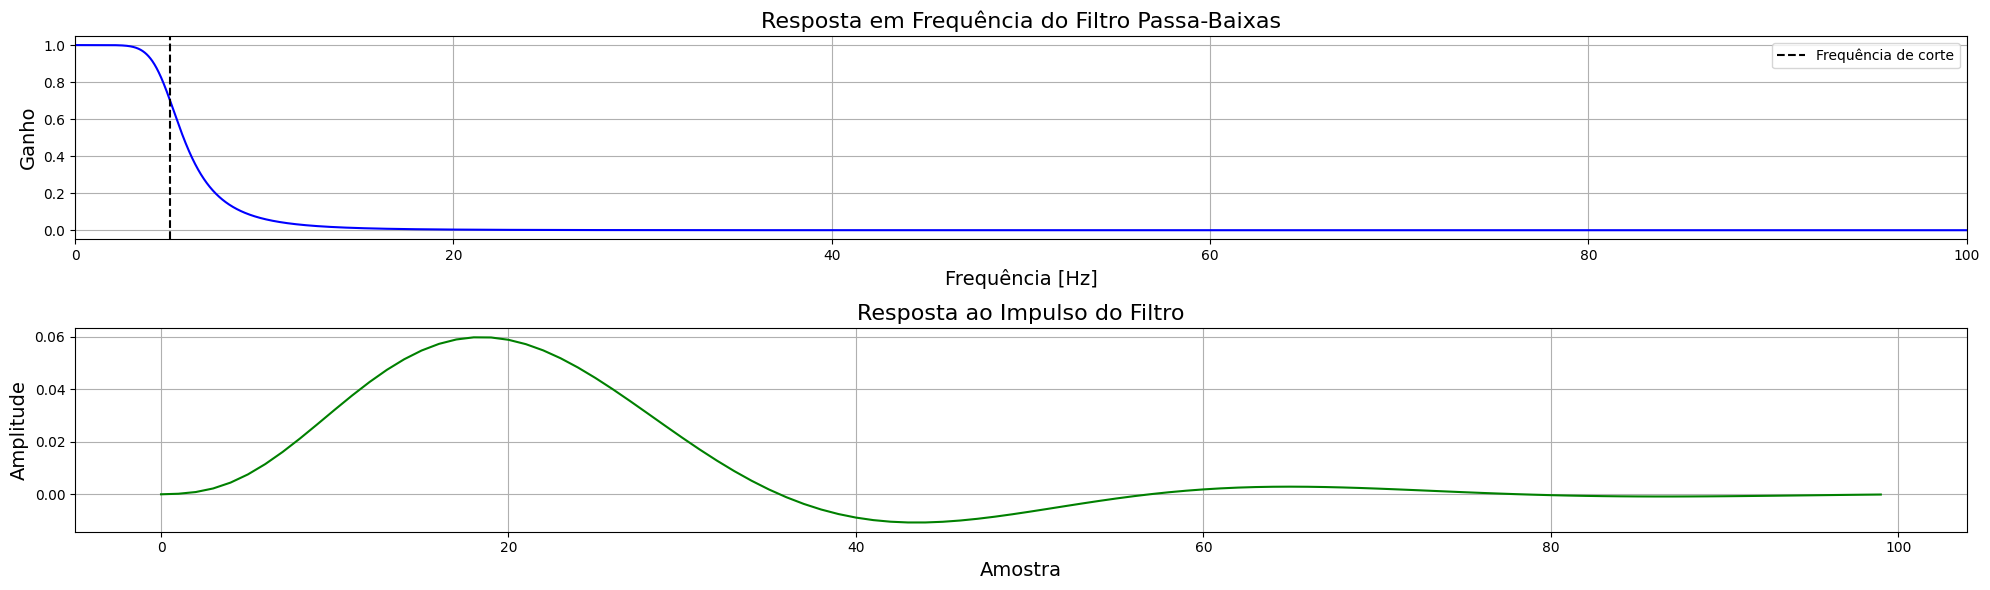

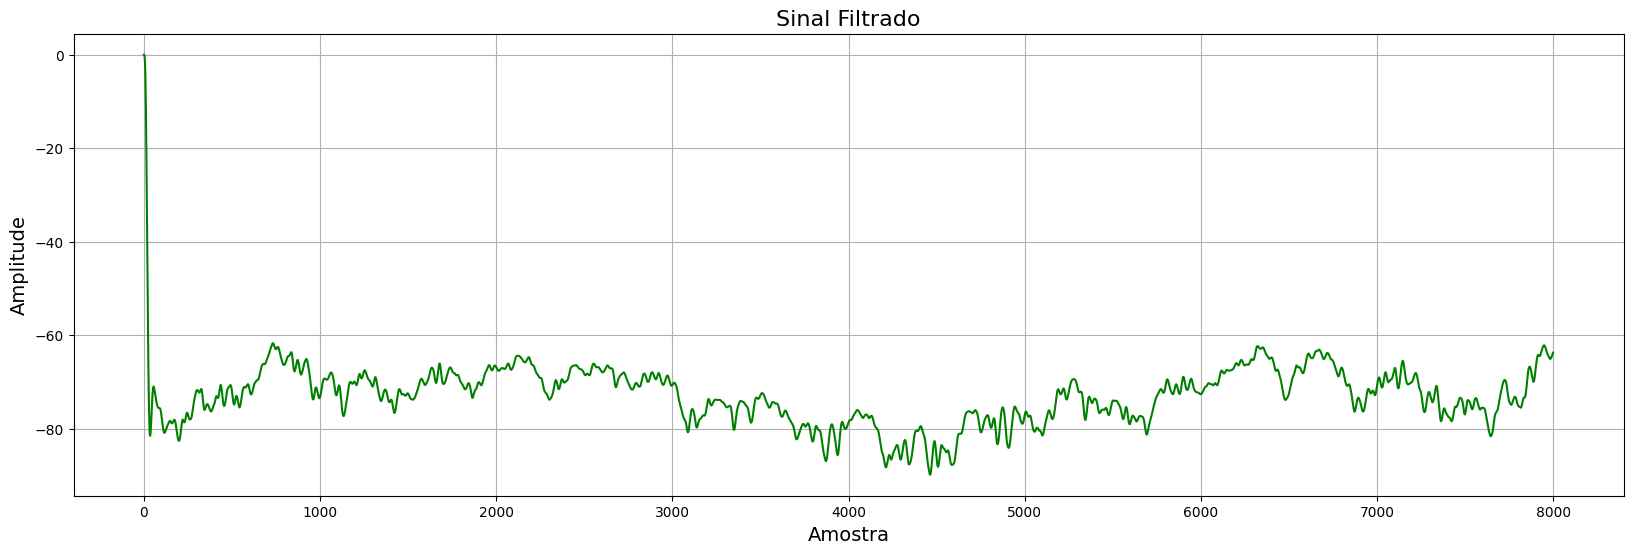

In [24]:
# Resposta da questão 2a

data = np.loadtxt('potencia.txt')

# Especificações do filtro
fs = 200.0  # taxa de amostragem, Hz
cutoff = 5.0  # frequência de corte desejada do filtro, Hz

# Projeto do filtro Butterworth
nyq = 0.5 * fs  # frequência de Nyquist
normal_cutoff = cutoff / nyq  # frequência de corte normalizada
b, a = butter(4, normal_cutoff, btype='low', analog=False)

# Ajustar o tamanho da figura para preencher a tela do Jupyter Notebook
plt.figure(figsize=(20, 6))

# Plotar a resposta em frequência do filtro
w, h = freqz(b, a, worN=8000)
plt.subplot(2, 1, 1)
plt.plot(0.5 * fs * w / np.pi, np.abs(h), 'b')
plt.axvline(cutoff, color='k', linestyle='--', label='Frequência de corte')
plt.xlim(0, 0.5 * fs)
plt.title("Resposta em Frequência do Filtro Passa-Baixas", fontsize=16)
plt.xlabel('Frequência [Hz]', fontsize=14)
plt.ylabel('Ganho', fontsize=14)
plt.grid()
plt.legend()

# Plotar a resposta ao impulso do filtro
impulse = np.zeros(100)
impulse[0] = 1  # impulso unitário
impulse_response = lfilter(b, a, impulse)
plt.subplot(2, 1, 2)
plt.plot(impulse_response, 'g')
plt.title("Resposta ao Impulso do Filtro", fontsize=16)
plt.xlabel('Amostra', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.grid()

plt.tight_layout()
plt.show()

# Aplicar o filtro aos dados
filtered_data = lfilter(b, a, data)

# Plotar o sinal filtrado
plt.figure(figsize=(20, 6))
plt.plot(filtered_data, 'g')
plt.title("Sinal Filtrado", fontsize=16)
plt.xlabel('Amostra', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.grid()
plt.show()




## Questão 2b (1.0 ponto)

Escreva uma função para processar uma janela de $N$ amostras do sinal desejado. $N$ deve ser escolhido em torno de 1 segundo de sinal, aproximadamente. A filtragem deve ser feita no domínio da DFT (pode ser utilizada alguma função para cálculo da fft em Python, como a função fft da biblioteca numpy).

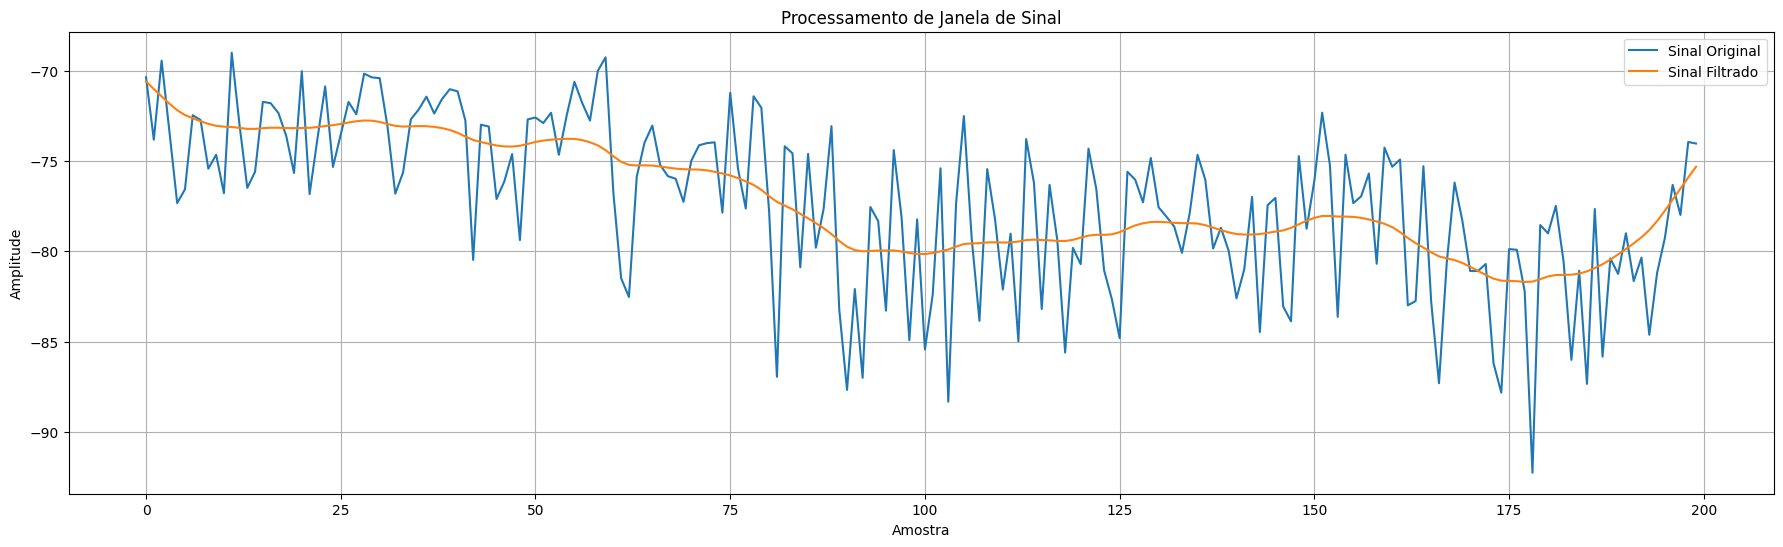

In [25]:
# Resposta da questão 2b

# Carregar os dados do arquivo potencia.txt
data = np.loadtxt('potencia.txt')

# Especificações do filtro
fs = 200.0  # taxa de amostragem, Hz
cutoff = 5.0  # frequência de corte desejada do filtro, Hz

# Supondo que temos uma janela de N amostras do sinal carregado anteriormente
window_size = int(fs)  # 1 segundo de sinal (200 amostras)
window_signal = data[:window_size]

# Processar a janela de sinal
filtered_window_signal = processar_janela(window_signal, fs, cutoff)

# Plotar o sinal original e o sinal filtrado
plt.figure(figsize=(22, 6))
plt.plot(window_signal, label='Sinal Original')
plt.plot(filtered_window_signal, label='Sinal Filtrado')
plt.title('Processamento de Janela de Sinal')
plt.xlabel('Amostra')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()



## Questão 2c (1.0  ponto)

Escreva uma função para combinar a saída do processamento de cada janela na saída do sistema, utilizando **um** dos métodos vistos (*overlap and add* ou *overlap and save*). Indique claramente o método escolhido.


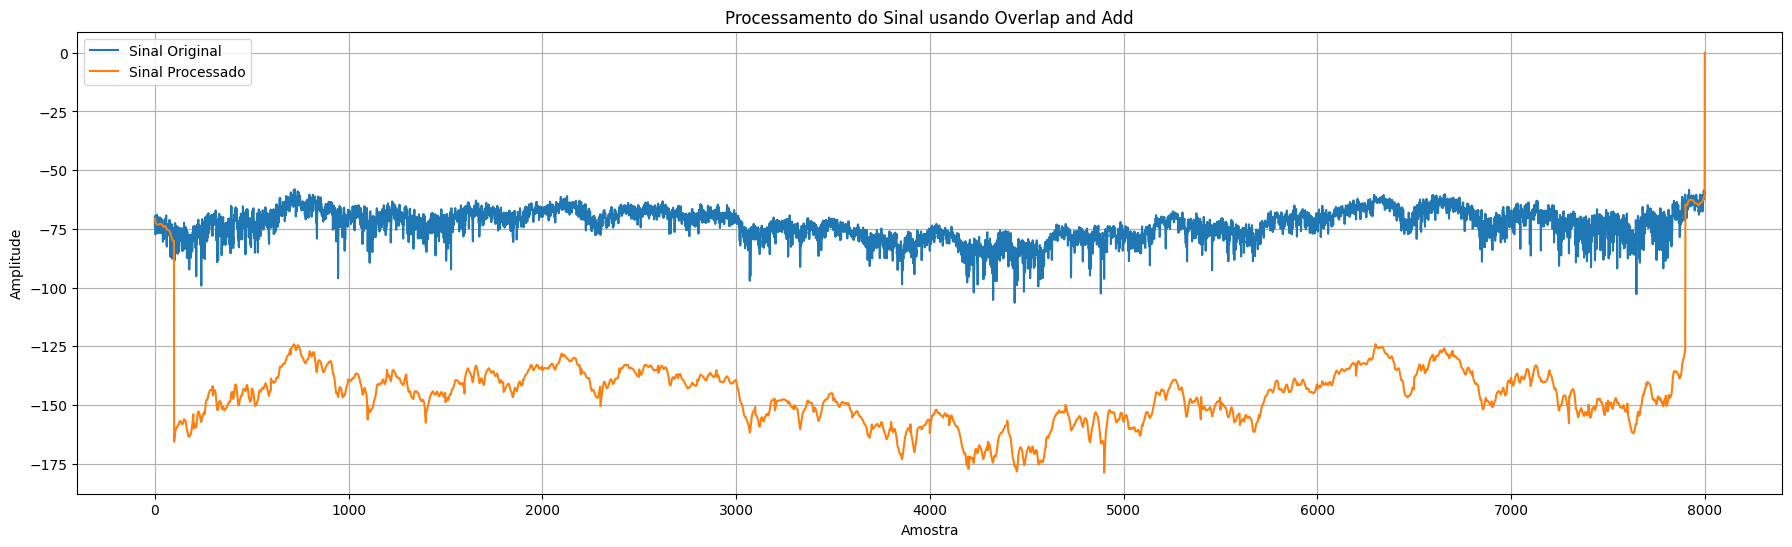

In [26]:
#Resposta da questão 2c

# Ler o arquivo potencia.txt
signal = np.loadtxt('potencia.txt')

# Definir parâmetros para o método Overlap and Add
window_size = 200  # 1 segundo de sinal
overlap_size = 100  # 50% de sobreposição

# Processar o sinal utilizando o método Overlap and Add
processed_signal = sobreposicao_e_adicao(signal, window_size, overlap_size)

# Plotar o sinal original e o sinal processado
plt.figure(figsize=(22, 6))
plt.plot(signal, label='Sinal Original')
plt.plot(processed_signal, label='Sinal Processado')
plt.title('Processamento do Sinal usando Overlap and Add')
plt.xlabel('Amostra')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()



## Questão 2d (1.0  ponto)

Plote o sinal de entrada e saída do sistema dado tanto pelo processamento em janelas como pelo processamento do sinal completo. Pode ser utilizada alguma função da biblioteca do python para calcular a saída do sistema usando o sinal completo.

Text(0.5, 0, 'Amostra')

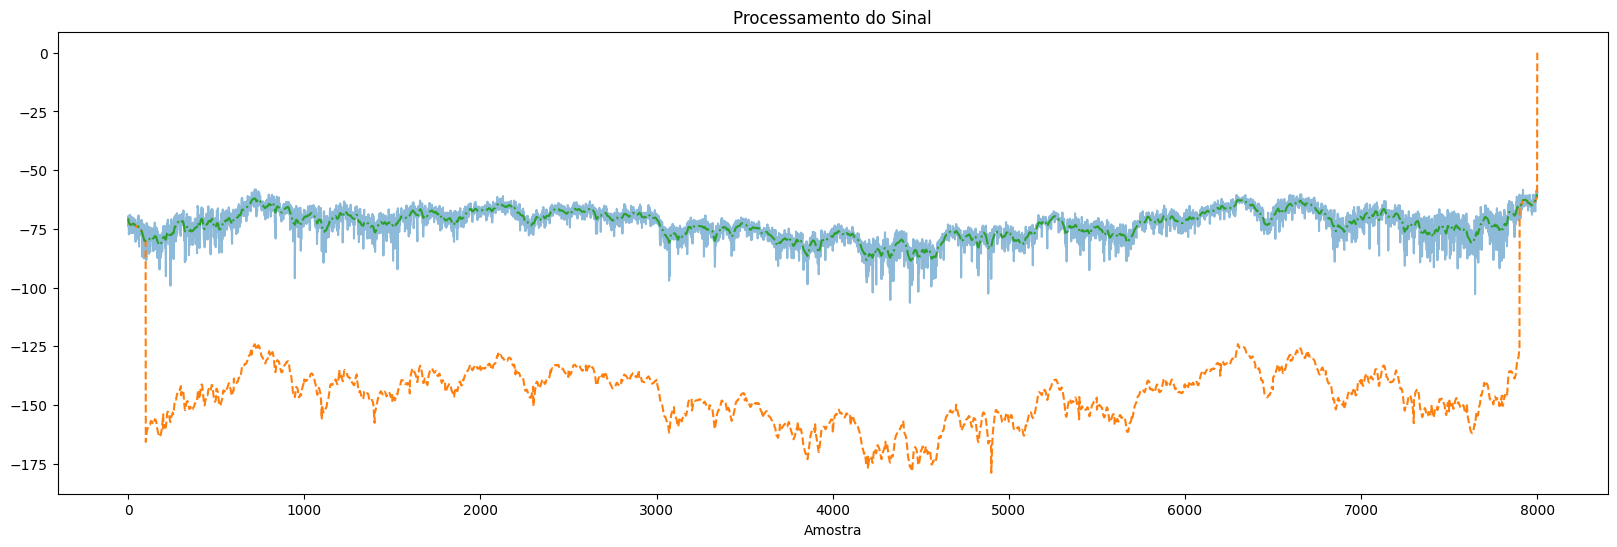

In [28]:
# Resposta da questão 2d

# Ler o arquivo potencia.txt
signal = np.loadtxt('potencia.txt')

# Definir parâmetros para o método Overlap and Add
window_size = 200  # 1 segundo de sinal
overlap_size = 100  # 50% de sobreposição

# Processar o sinal utilizando o método Overlap and Add
processed_signal_oa = sobreposicao_e_adicao(signal, window_size, overlap_size)

# Processar o sinal completo de uma vez
processed_signal_complete = processar_sinal_completo(signal)

# Plotar o sinal original, o sinal processado por janelas e o sinal processado completo
plt.figure(figsize=(20, 6))
plt.plot(signal, label='Sinal Original', alpha=0.5)
plt.plot(processed_signal_oa, label='Sinal Processado (Overlap and Add)', linestyle='--')
plt.plot(processed_signal_complete, label='Sinal Processado (Completo)', linestyle='-.')
plt.title('Processamento do Sinal')
plt.xlabel('Amostra')



# Questão 3

A equação diferença para um filtro FIR de tamanho $N$ pode ser escrita como:

$$
\begin{align}
	y\left[n\right] &= h_0 x\left[n\right] + h_1 x\left[n-1\right] + h_2 x\left[n-2\right] + h_3 \left[n-3\right] + \ldots + h_{N-1} x\left[n - \left(N- 1\right)\right] \\
	       &= \sum_{k=0}^{N-1} h_k x\left[n - k\right]
\end{align}
$$

Os coeficientes do filtro, ou \textit{taps}, são expressados usando a variável $h_k$ para enfatizar que os próprios coeficientes representam a resposta ao impulso do filtro. A resposta em frequência do filtro é:

$$
\begin{align}
	H\left( \Omega \right) = \frac{Y\left( \Omega \right)}{X\left( \Omega \right)} = \sum_{k=0}^{N-1} h_k e^{-j \Omega k}
\end{align}
$$

Como $H\left( \Omega \right)$ é uma função com período $2 \pi$ da variável contínua $\Omega$, é suficiente especificar $H\left( \Omega \right)$ em apenas um período $0 \leq \Omega < 2 \pi$.

Em muitas aplicações, a resposta em magnitude desejada do filtro $\left|H_d \left( \Omega \right)\right|$ é conhecida, mas não os coeficientes $h_k$ do filtro. A questão é, então, determinar os coeficientes do filtro a partir da resposta em magnitude desejada. Podemos fazer isso simplesmente amostrando a resposta em frequência desejada $\left|H_d \left( \Omega \right)\right|$ com $N$ amostras em um período, e então fazendo a DFT inversa dessas amostras (obtendo $h\left[n\right]$). Note que a definição dos coeficientes $h_k$ é suficiente para determinar o sistema do filtro FIR. Além disso, como $H \left( \Omega \right)$ foi obtido amostrando $\left|H_d \left( \Omega \right)\right|$ para algumas frequências, garantimos que a resposta em frequência do filtro projeto será igual a resposta em frequência desejada ao menos nos valores de amostragem. Finalmente, observe que, ao fazer a DFT inversa, alguns coeficientes $h_k$ podem ter uma pequena componente imaginária que deve ser descartada para o projeto de um filtro real.



## Questão 3a (1.0  ponto)

Considere então um sinal de ECG amostrado a uma taxa de $500$ Hz. Projete um filtro digital FIR através da amostragem de frequência passa-baixas com frequência de corte igual a $50$ Hz.

Plote a resposta ao impulso $h\left[n\right]$ e a resposta em frequência $H\left(\Omega\right)$ do filtro para $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com a resposta em frequência desejada.

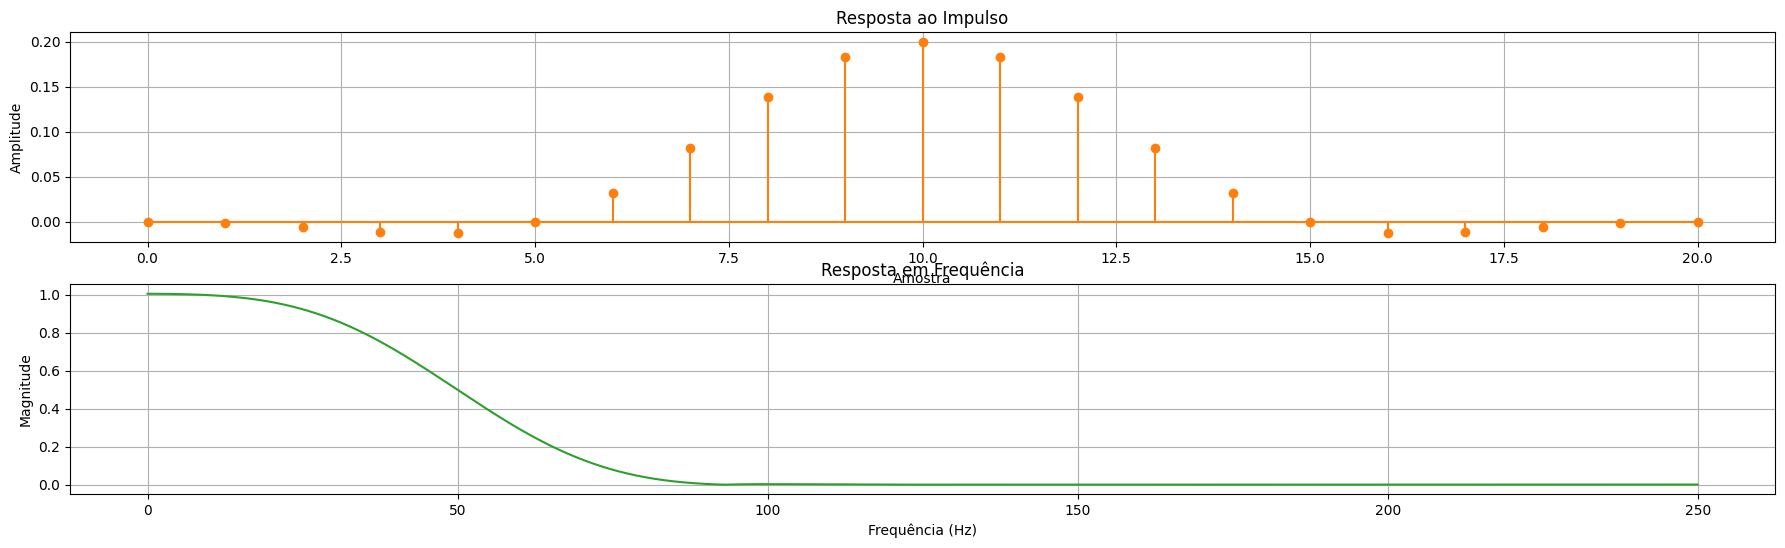

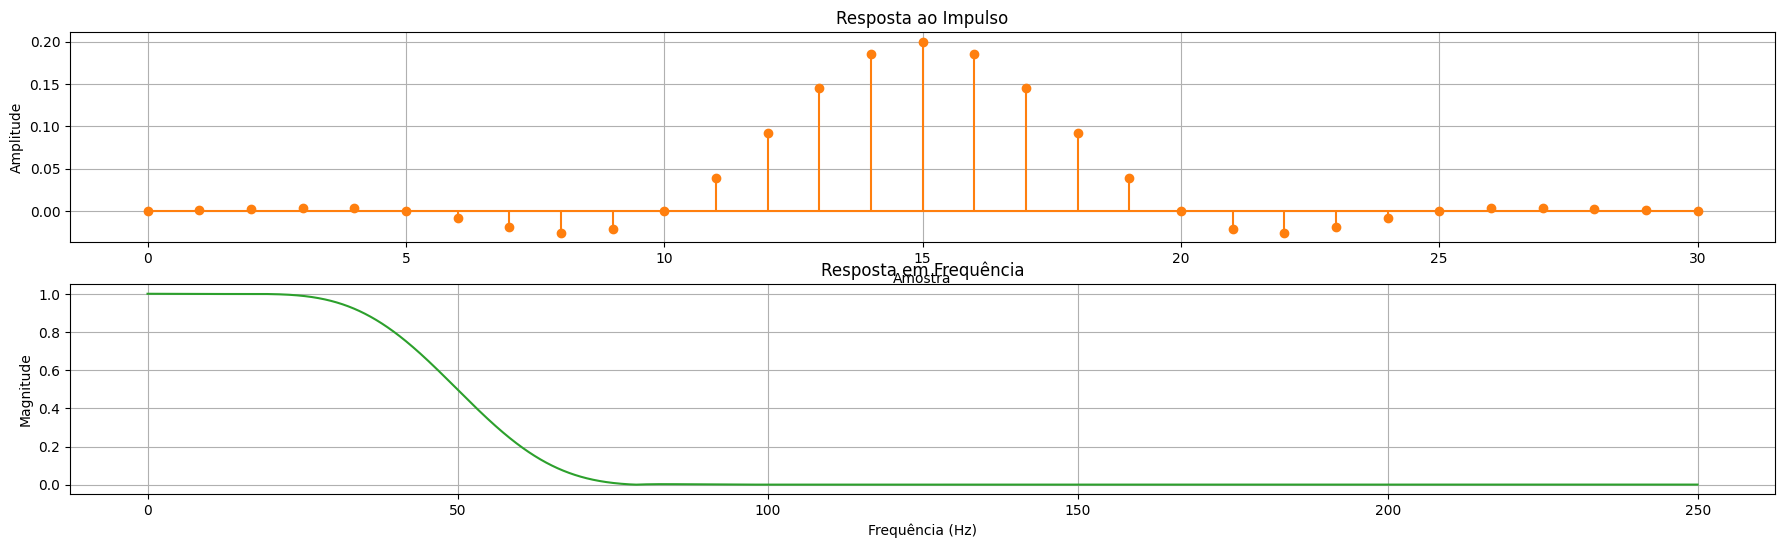

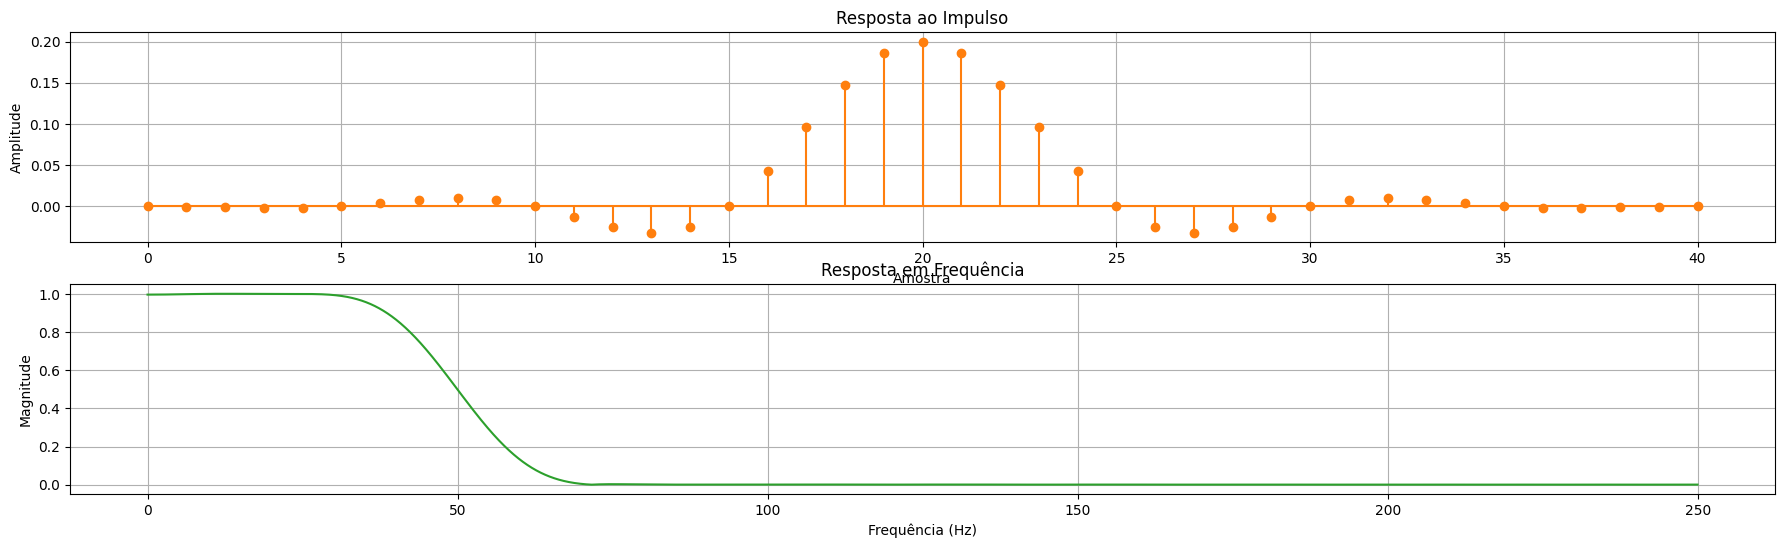

In [29]:
# Resposta da questão 3a

def plota_resposta_filtro(h, fs):
    # Resposta ao impulso
    plt.figure(figsize=(22, 6))
    plt.subplot(2, 1, 1)
    plt.stem(h, linefmt='C1-', markerfmt='C1o', basefmt='C1-')
    plt.title('Resposta ao Impulso')
    plt.xlabel('Amostra')
    plt.ylabel('Amplitude')
    plt.grid()

    # Resposta em frequência
    w, H = freqz(h, worN=8000)
    plt.subplot(2, 1, 2)
    plt.plot(w / np.pi * (fs / 2), np.abs(H), color='C2')
    plt.title('Resposta em Frequência')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

# Parâmetros do filtro
fc = 50  # Frequência de corte
fs = 500  # Frequência de amostragem

# Tamanhos dos filtros
Ns = [21, 31, 41]

# Gerar e plotar filtros
for N in Ns:
    h = filtro_passa_baixa_ideal(fc, fs, N)
    plota_resposta_filtro(h, fs)




## Questão 3b (1.0  ponto)

A resposta ao impulso do filtro do item anterior deveria ser uma função *sinc*, que é uma função com suporte infinito. Porém, a amostragem amostra apenas a parte para $n$ positivo, gerando uma descontinuidade e uma resposta em frequência mais pobre. Uma forma de melhorar essa amostragem é centralizar a função *sinc* - para isso, devemos multiplicar a resposta em frequência do filtro $H\left(\Omega\right)$ por $e^{-j \Omega \frac{\left(N - 1\right)}{2}}$. Utilize essa técnica para gerar novos filtros com $N = 21$, $N = 31$ e $N = 41$. Compare os filtros com os filtros do item anterior com o mesmo tamanho.

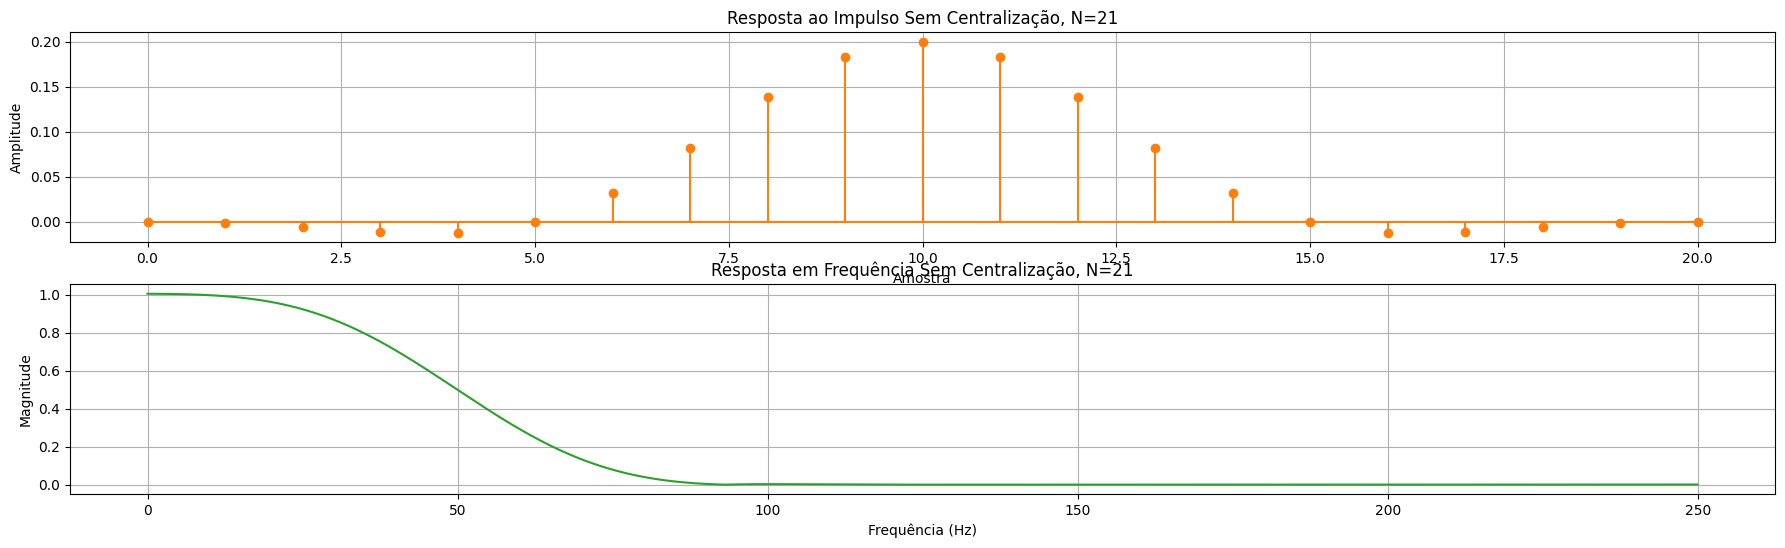

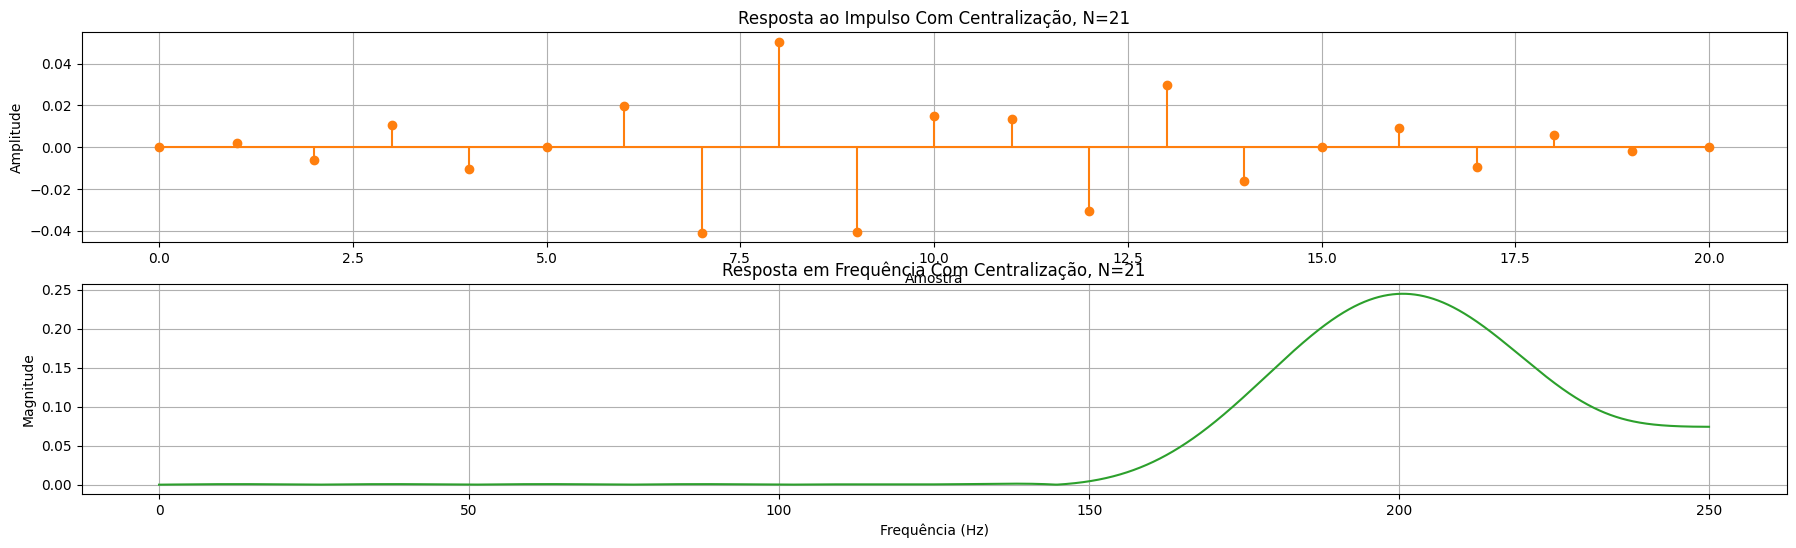

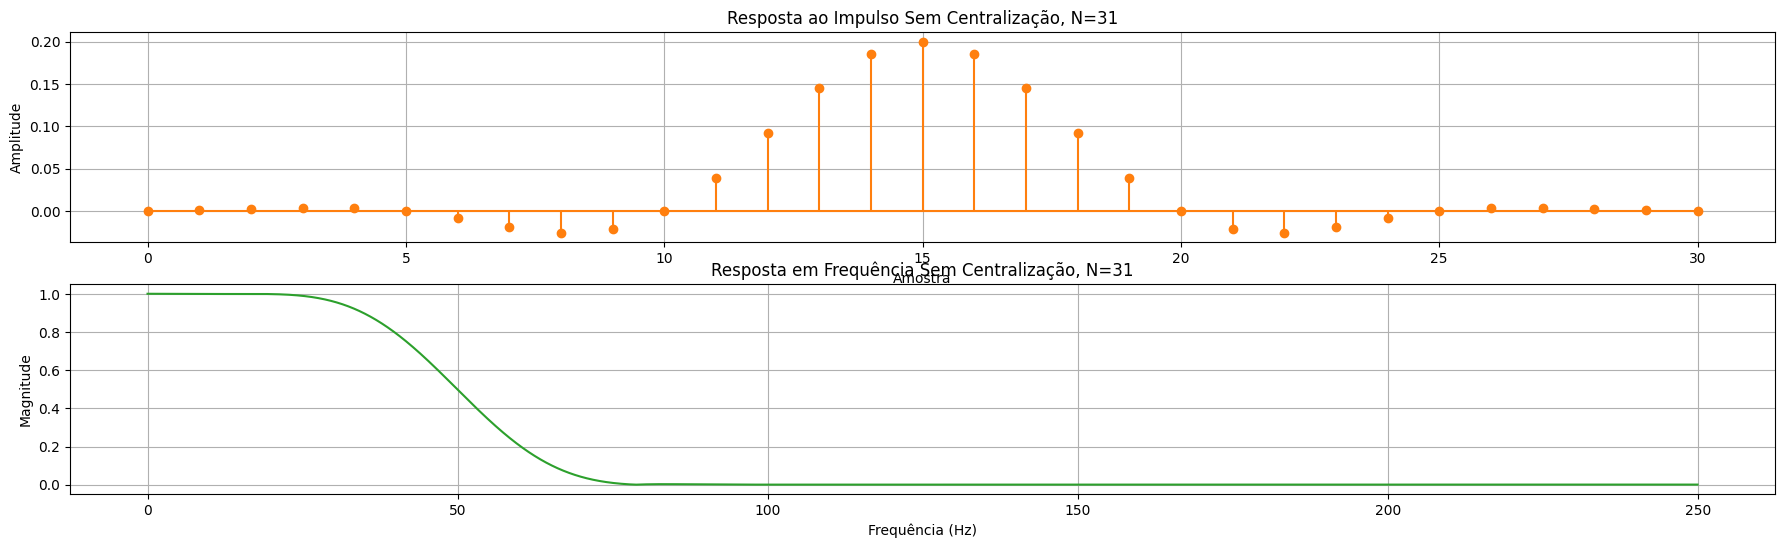

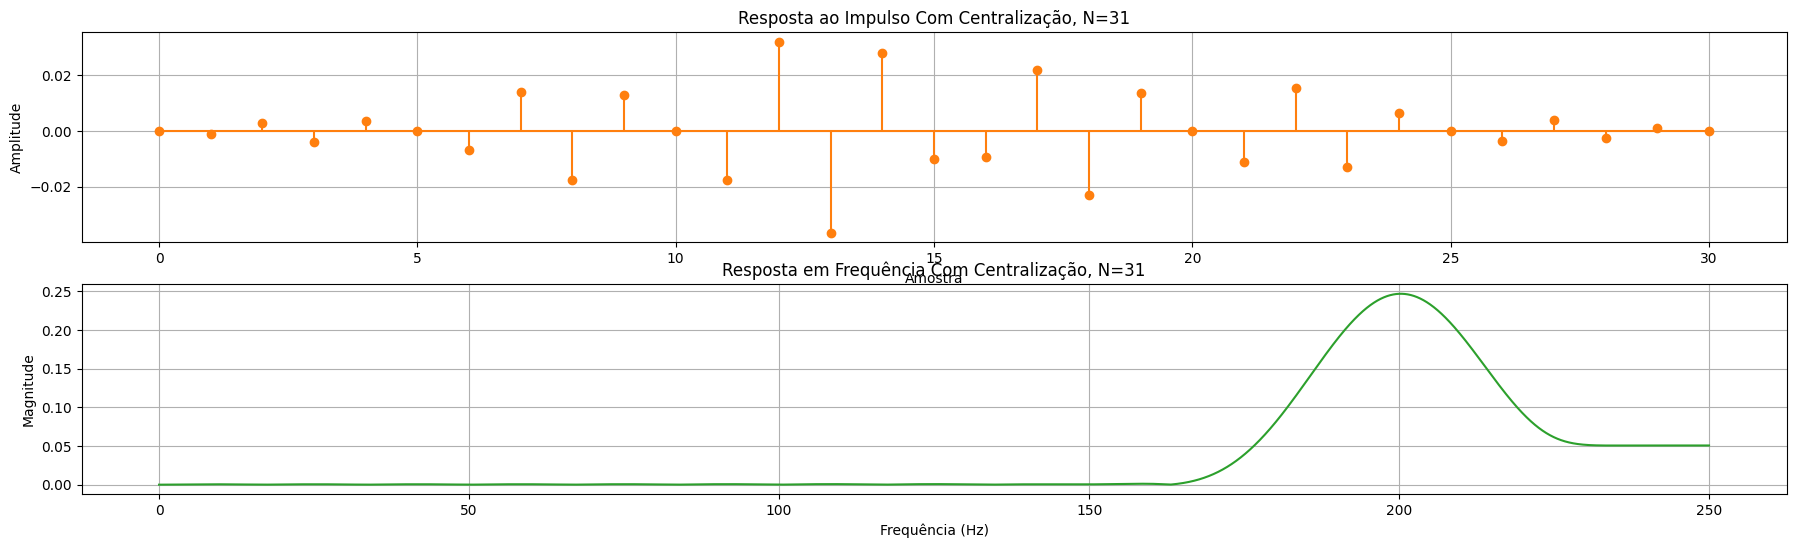

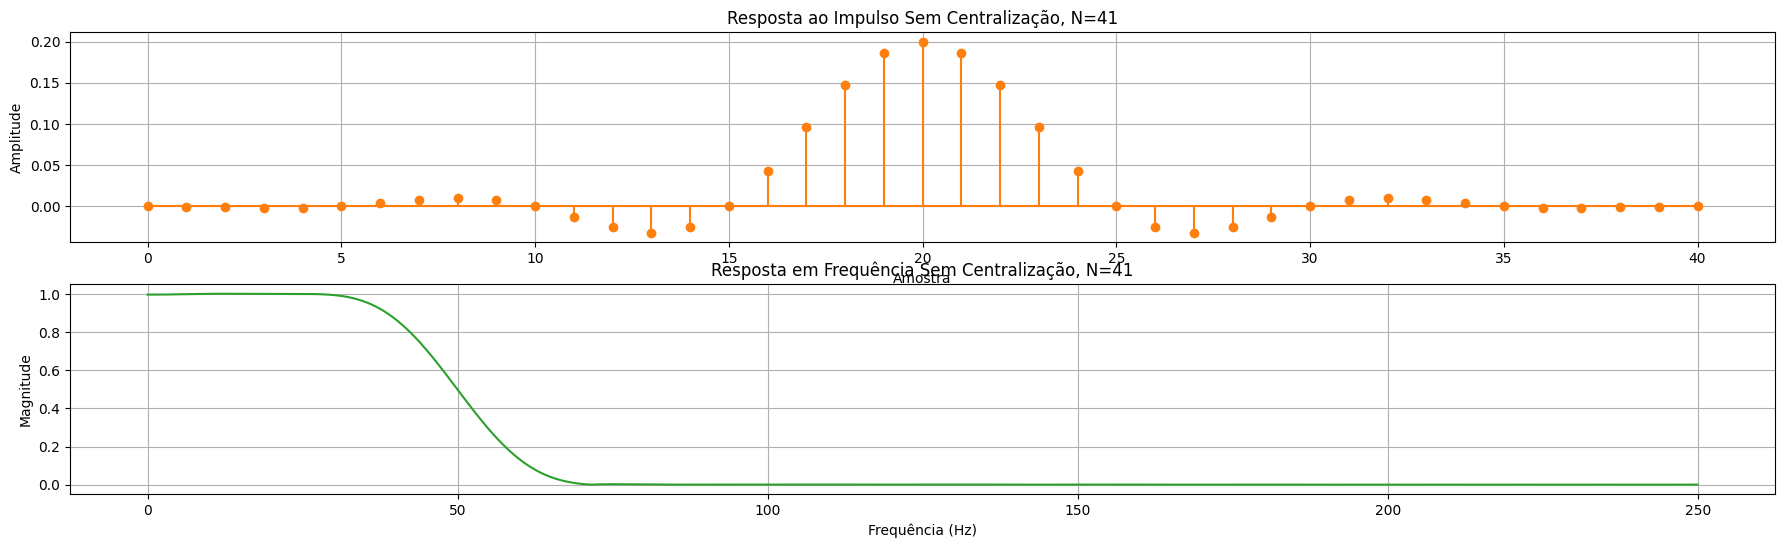

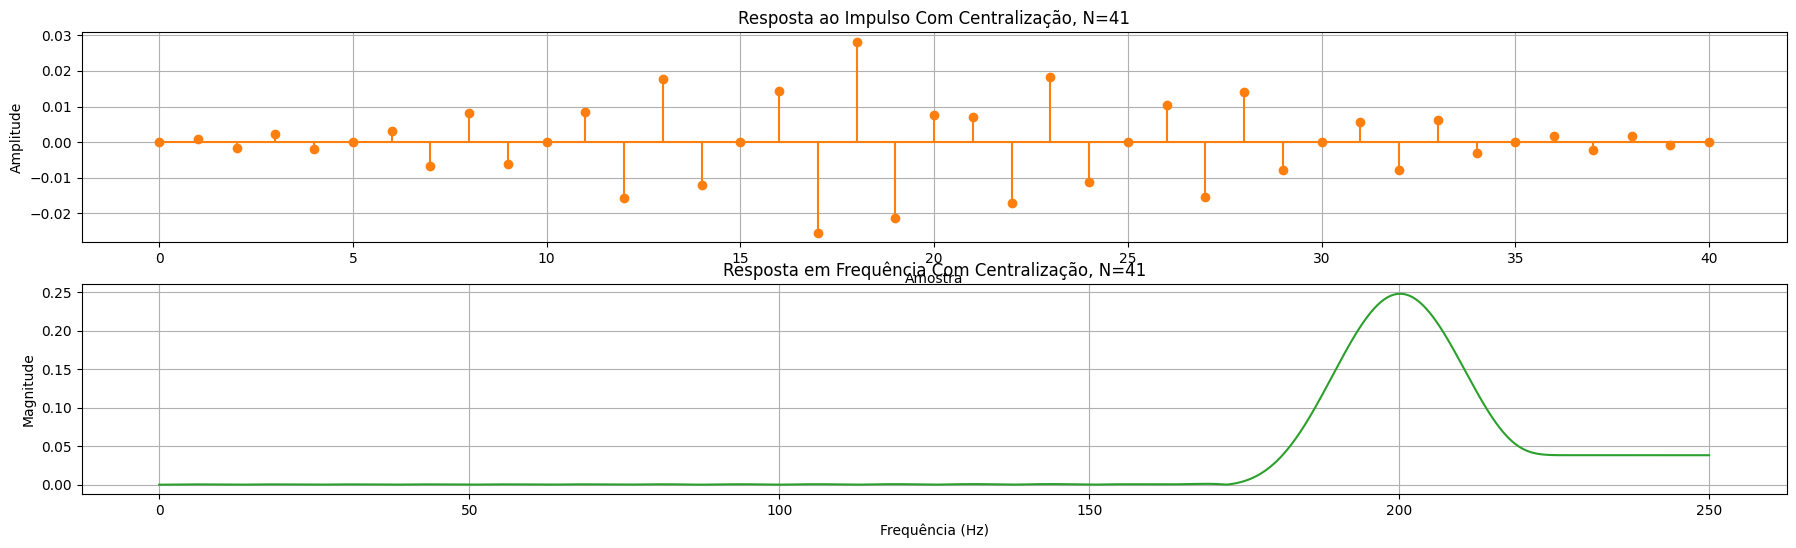

In [31]:
# Resposta da questão 3b

def plota_resposta_filtro(h, fs, titulo=''):
    # Resposta ao impulso
    plt.figure(figsize=(22, 6))
    plt.subplot(2, 1, 1)
    plt.stem(h, linefmt='C1-', markerfmt='C1o', basefmt='C1-')
    plt.title(f'Resposta ao Impulso {titulo}')
    plt.xlabel('Amostra')
    plt.ylabel('Amplitude')
    plt.grid()

    # Resposta em frequência
    w, H = freqz(h, worN=8000)
    plt.subplot(2, 1, 2)
    plt.plot(w / np.pi * (fs / 2), np.abs(H), color='C2')
    plt.title(f'Resposta em Frequência {titulo}')
    plt.xlabel('Frequência (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

# Parâmetros do filtro
fc = 50  # Frequência de corte
fs = 500  # Frequência de amostragem

# Tamanhos dos filtros
Ns = [21, 31, 41]

# Gerar e plotar filtros
for N in Ns:
    h = filtro_passa_baixa_ideal(fc, fs, N)
    plota_resposta_filtro(h, fs, titulo=f'Sem Centralização, N={N}')

    h_centralizado = centralizar_sinc(h)
    plota_resposta_filtro(h_centralizado, fs, titulo=f'Com Centralização, N={N}')



## Questão 3c (1.0  ponto)

Aplique o filtro com $N = 41$ no sinal do arquivo "noisy\_ecg\_data\_3.mat". Compare o sinal de entrada com o sinal de saída. O que acontece com os picos do ECG?

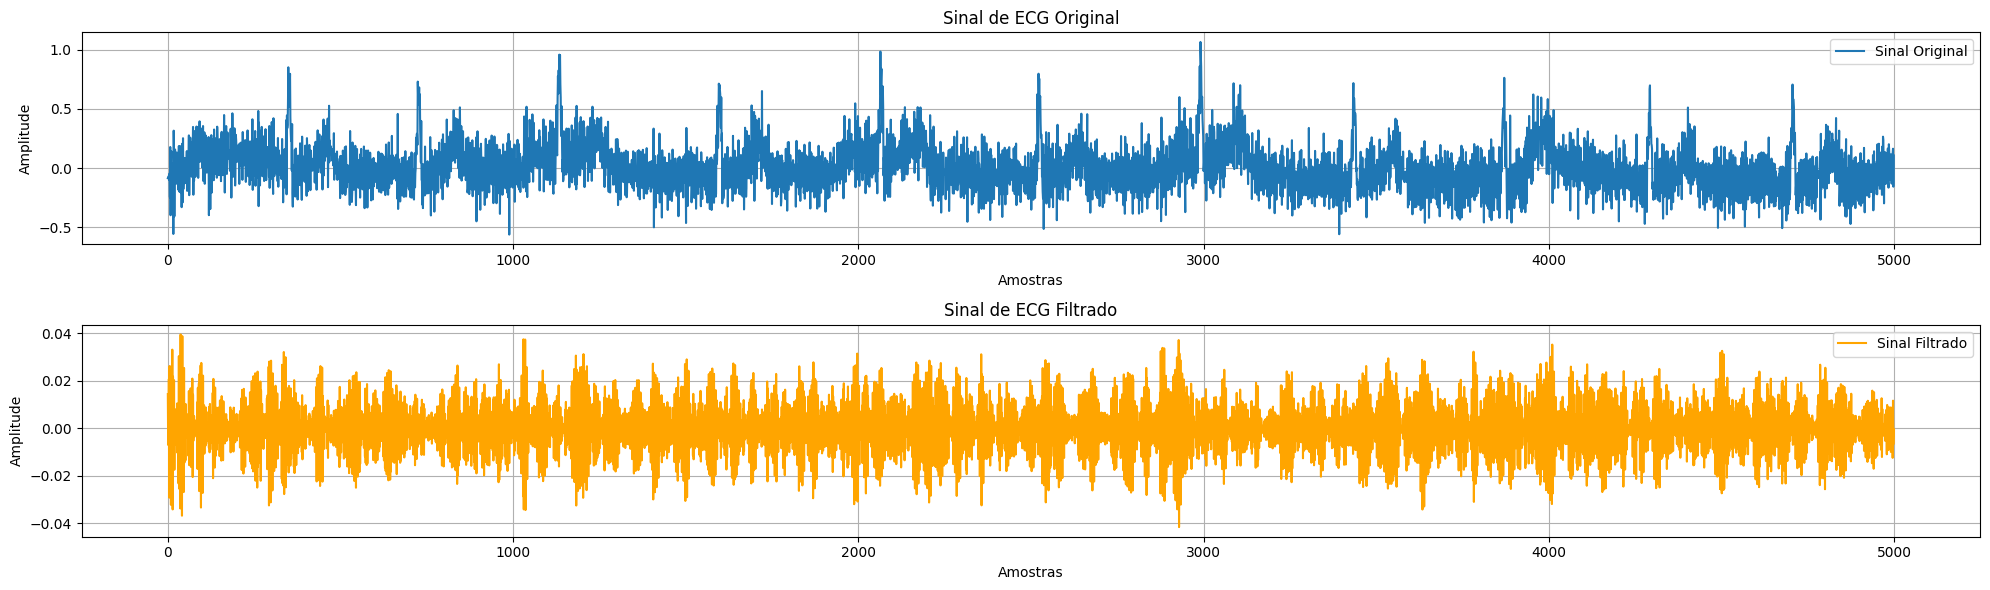

In [32]:
#Resposta da questão 3c

# Carregar os dados do arquivo .mat e extrair o sinal de ECG ruidoso
sinal = sp.io.loadmat('noisy_ecg_data_3.mat')['noisy_ecg_3'].ravel()

# Aplicar o filtro ao sinal
fc = 50  # Frequência de corte
fs = 500  # Frequência de amostragem
N = 41  # Tamanho do filtro
h = filtro_passa_baixa_ideal(fc, fs, N)
h_centralizado = centralizar_sinc(h)

# Filtrar o sinal
sinal_filtrado = np.convolve(sinal, h_centralizado, mode='same')

# Plotar o sinal original e o sinal filtrado
plt.figure(figsize=(20, 6))
plt.subplot(2, 1, 1)
plt.plot(sinal, label='Sinal Original')
plt.title('Sinal de ECG Original')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(sinal_filtrado, label='Sinal Filtrado', color='orange')
plt.title('Sinal de ECG Filtrado')
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



## Questão 3d (1.0  ponto)

Utilize a técnica de *zero-phase filtering* com o filtro do item anterior. Compare a saída do sistema com e sem a aplicação da técnica.

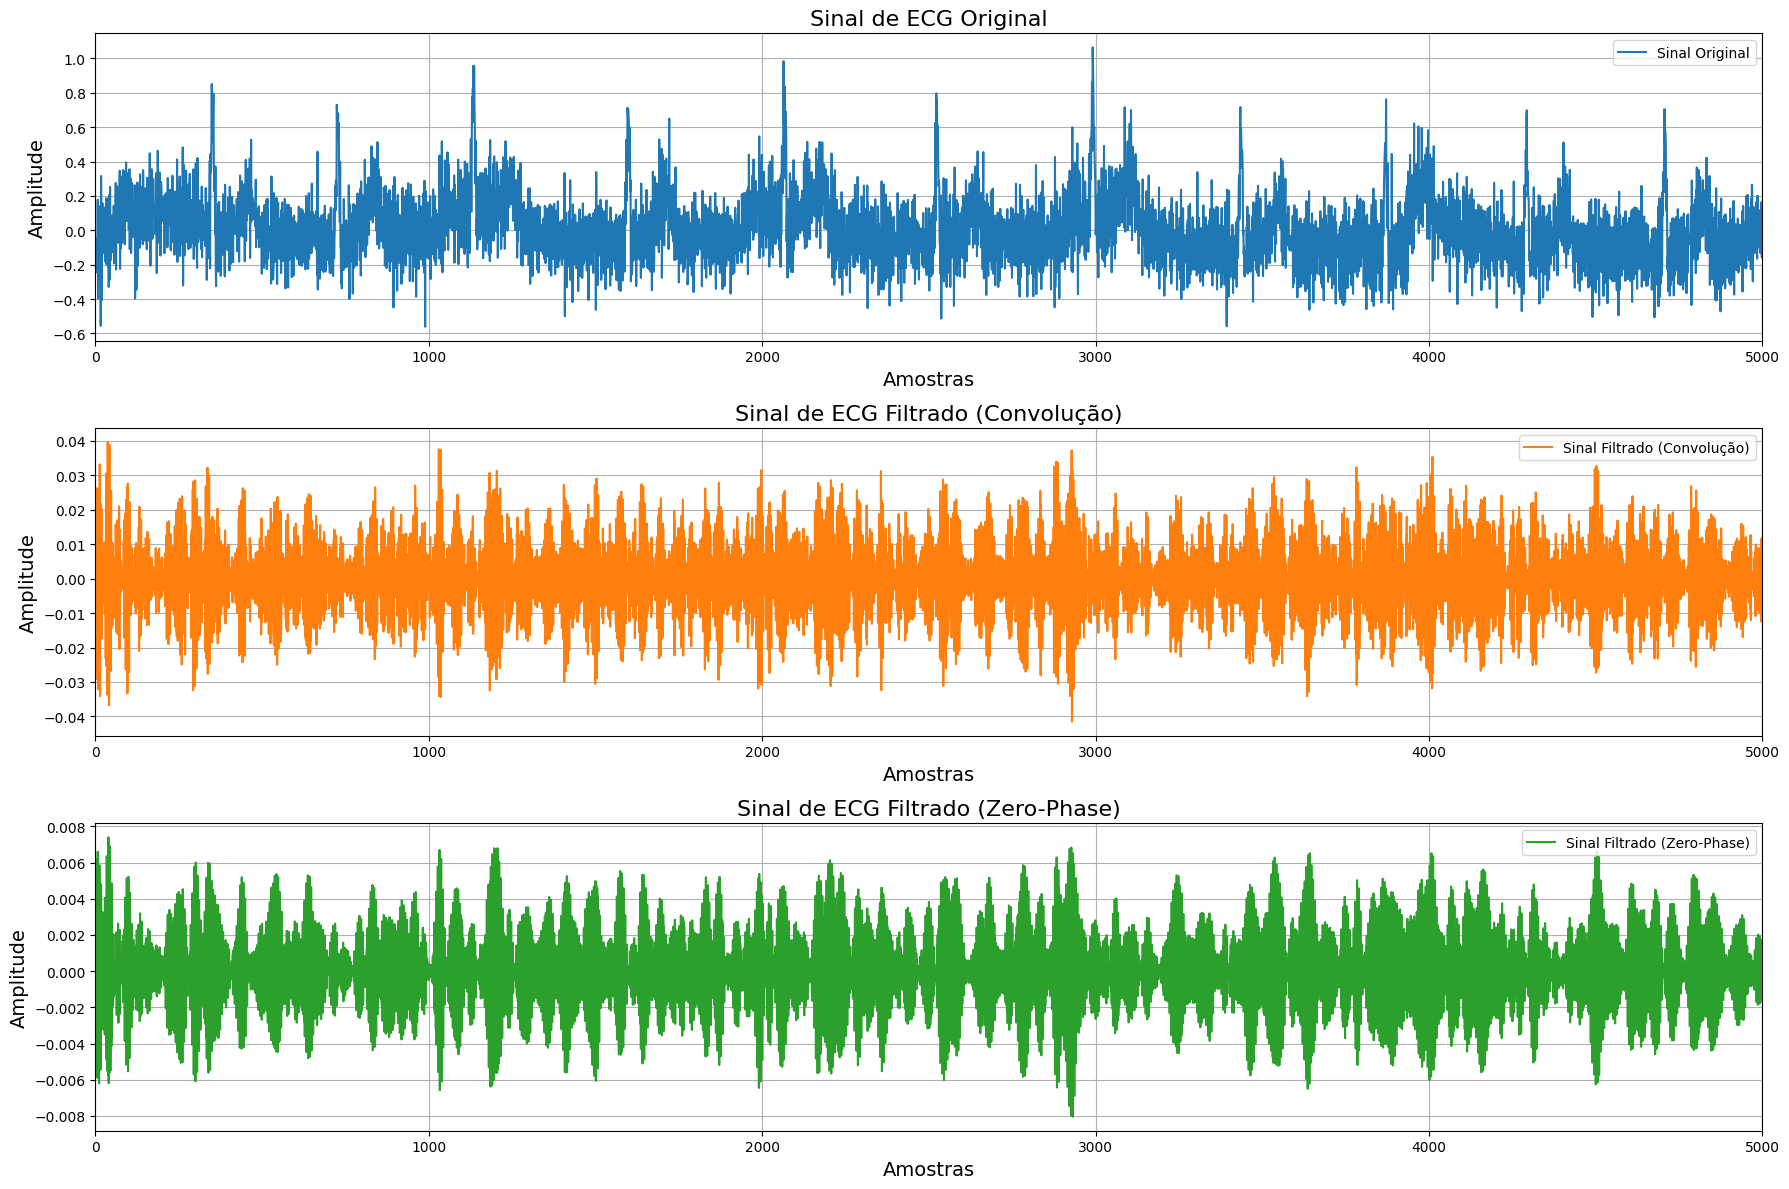

In [35]:
#Resposta da questão 3d

# Carregar os dados do arquivo .mat e extrair o sinal de ECG ruidoso
sinal = sp.io.loadmat('noisy_ecg_data_3.mat')['noisy_ecg_3'].ravel()

# Parâmetros do filtro
fc = 50  # Frequência de corte
fs = 500  # Frequência de amostragem
N = 41  # Tamanho do filtro

# Obter os coeficientes do filtro
h = filtro_passa_baixa_ideal(fc, fs, N)
h_centralizado = centralizar_sinc(h)

# Aplicar o filtro ao sinal usando convolução simples
sinal_filtrado_conv = np.convolve(sinal, h_centralizado, mode='same')

# Aplicar o filtro ao sinal usando zero-phase filtering
sinal_filtrado_zero_phase = filtfilt(h_centralizado, 1, sinal)

# Plotar o sinal original e os sinais filtrados
plt.figure(figsize=(18, 12))

plt.subplot(3, 1, 1)
plt.plot(sinal, label='Sinal Original', color='#1f77b4')
plt.title('Sinal de ECG Original', fontsize=16)
plt.xlabel('Amostras', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(loc='upper right')
plt.grid()
plt.xlim(0, len(sinal))

plt.subplot(3, 1, 2)
plt.plot(sinal_filtrado_conv, label='Sinal Filtrado (Convolução)', color='#ff7f0e')
plt.title('Sinal de ECG Filtrado (Convolução)', fontsize=16)
plt.xlabel('Amostras', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(loc='upper right')
plt.grid()
plt.xlim(0, len(sinal_filtrado_conv))

plt.subplot(3, 1, 3)
plt.plot(sinal_filtrado_zero_phase, label='Sinal Filtrado (Zero-Phase)', color='#2ca02c')
plt.title('Sinal de ECG Filtrado (Zero-Phase)', fontsize=16)
plt.xlabel('Amostras', fontsize=14)
plt.ylabel('Amplitude', fontsize=14)
plt.legend(loc='upper right')
plt.grid()
plt.xlim(0, len(sinal_filtrado_zero_phase))

plt.tight_layout()
plt.show()
